# Описание проекта
В рамках этой работы мы разрабатываем рекомендательную систему на основе данных о взаимодействии пользователей с книгами. Цель — предсказать, какую оценку пользователь поставит конкретной книге, исходя из признаков пользователя, книги и их взаимодействий.
Мы подходим к задаче как к многоклассовой классификации с метрикой качества precision (micro).

# Датасет: Goodbooks-10k
Ссылка - https://github.com/zygmuntz/goodbooks-10k
Этот датасет содержит 6 миллионов пользовательских оценок для 10 000 наиболее популярных книг на платформе Goodreads. Помимо самих оценок, в составе датасета:

## books.csv — 
метаданные о книгах: название, автор, средняя оценка, год публикации, ISBN и др.
## ratings.csv — 
более 6 млн оценок пользователей (от 1 до 5), отсортированы по времени
## to_read.csv — 
список книг, добавленных пользователями в "Хочу прочитать"
## book_tags.csv — 
пользовательские теги/жанры/полки, назначенные книгам; представлены как book_id, tag_id, count
## tags.csv — 
словарь: tag_id → tag_name

Размеры:
ratings.csv — ~69 MB
to_read.csv — ~1 млн записей

## Мы сводим задачу построения рекомендательной системы к многоклассовой классификации, в которой необходимо предсказать, какую оценку (от 1 до 5) пользователь поставит книге.

Такой подход позволяет:

понять, какие оценки система предсказывает чаще всего;

анализировать ошибки между соседними классами (например, 4 вместо 5);

использовать понятные метрики качества, такие как precision, recall, confusion matrix, micro-усреднённая precision.

Мы выбираем метрику precision (micro) как основную, так как она особенно чувствительна к дисбалансу классов, и будет честно учитывать ошибки во всех классах.

# Imports

In [5]:
import csv
import gc
import json
import joblib
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import os
import pandas as pd
import requests
import seaborn as sns
import time
import torch
import xml.etree.ElementTree as ET

from catboost import CatBoostClassifier
from collections import Counter
from isbnlib import is_isbn10, is_isbn13
from nltk.corpus import stopwords
from pytorch_tabnet.tab_model import TabNetClassifier
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.metrics import (
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import OneHotEncoder
from tqdm import tqdm
from urllib.parse import quote_plus

# Downloads

In [32]:
ratings =  pd.read_csv(r'D:\ML\LS\Rec_sys_project\Content_based\raw\ratings.csv')
tags =  pd.read_csv(r'D:\ML\LS\Rec_sys_project\Content_based\raw\tags.csv')
books = pd.read_csv(r'D:\ML\LS\Rec_sys_project\Content_based\raw\books.csv')
book_tags = pd.read_csv(r'D:\ML\LS\Rec_sys_project\Content_based\raw\book_tags.csv')
to_read = pd.read_csv(r'D:\ML\LS\Rec_sys_project\Content_based\raw\to_read.csv')

In [33]:
books.head()

,book_id,goodreads_book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,...,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,...,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...


In [65]:
# --- Восстановим isbn13_str как строку без экспоненты и без десятичной точки ---
def convert_isbn13(isbn):
    if pd.isna(isbn):
        return pd.NA
    try:
        # Преобразуем float -> int -> str
        isbn_str = str(int(isbn))
        if len(isbn_str) == 13:
            return isbn_str
        else:
            return pd.NA  # отсекаем явно битые
    except:
        return pd.NA

books3 = books.copy()
books3['isbn13_str'] = books3['isbn13'].apply(convert_isbn13)

# --- Проверим валидность ---
from isbnlib import is_isbn13

books3['isbn_valid'] = books3['isbn13_str'].apply(lambda x: is_isbn13(x) if pd.notna(x) else False)

# --- Валидные ISBN ---
valid_books3 = books3[books3['isbn_valid']].copy()

# --- Отчёт ---
print(f"Всего записей: {len(books3)}")
print(f"Пустых ISBN-13: {books3['isbn13_str'].isna().sum()}")
print(f"Валидных ISBN-13: {len(valid_books3)}")

# Пример валидных
print(valid_books3['isbn13_str'].head())

Всего записей: 10000
Пустых ISBN-13: 593
Валидных ISBN-13: 956
1     9780439554930
6     9780618260300
31    9780142000670
32    9780739326220
35    9780385732550
Name: isbn13_str, dtype: object


In [67]:
# --- Преобразуем isbn в строку и проверим ---
books['isbn_str'] = books['isbn'].astype(str)
books['isbn_valid'] = books['isbn_str'].apply(lambda x: is_isbn10(x) or is_isbn13(x))
valid_books = books[books['isbn_valid']].copy()

print(f"Валидных обычных ISBN: {len(valid_books)} / {len(books)}")
print(valid_books['isbn_str'].head())

Валидных обычных ISBN: 2690 / 10000
8     1416524797
10    1594480001
17    043965548X
33    1612130291
45    1565125606
Name: isbn_str, dtype: object


In [75]:
books_final = books.copy()

# --- Преобразования ---
books_final['isbn_str'] = books_final['isbn'].astype(str)

def recover_isbn13(x):
    try:
        return str(int(float(x)))
    except:
        return pd.NA

books_final['isbn13_str'] = books_final['isbn13'].apply(recover_isbn13)

def choose_best_isbn(row):
    if pd.notna(row['isbn_str']) and (is_isbn10(row['isbn_str']) or is_isbn13(row['isbn_str'])):
        return row['isbn_str']
    elif pd.notna(row['isbn13_str']) and is_isbn13(row['isbn13_str']):
        return row['isbn13_str']
    else:
        return pd.NA

books_final['best_isbn'] = books_final.apply(choose_best_isbn, axis=1)

# --- Пути сохранения ---
save_path = r'D:\ML\LS\Rec_sys_project\Content_based\data\book_descr_final.csv'
partial_path = r'D:\ML\LS\Rec_sys_project\Content_based\data\book_descr_partial_final.csv'

# --- Частичное сохранение ---
if os.path.exists(partial_path):
    partial = pd.read_csv(partial_path)
    processed_ids = set(partial['book_id'])
    descriptions = partial.to_dict(orient='records')
    print(f"Найдено частичное сохранение: {len(processed_ids)} книг уже обработано.")
else:
    processed_ids = set()
    descriptions = []

books_to_process = books_final[~books_final['book_id'].isin(processed_ids)]
print(f"Начинаем сбор описаний: {len(books_to_process)} новых книг")

# --- Заголовки ---
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/115.0.0.0 Safari/537.36'
}

# --- Парсинг с tqdm ---
start_time = time.time()

for _, row in tqdm(books_to_process.iterrows(), total=len(books_to_process), desc="Сбор описаний", unit="книг"):
    book_id = row['book_id']
    title = row['title']
    author = row['authors']
    isbn = row['best_isbn']
    desc = None

    # --- Google Books ---
    if pd.notna(isbn):
        try:
            url = f'https://www.googleapis.com/books/v1/volumes?q=isbn:{isbn}'
            r = requests.get(url, headers=headers, timeout=10)
            data = r.json()
            if 'items' in data and data['items']:
                volume_info = data['items'][0].get('volumeInfo', {})
                desc = volume_info.get('description', None)
        except Exception as e:
            print(f"[!] Ошибка на ISBN {isbn}: {e}")

    # --- Open Library fallback ---
    if desc is None and pd.notna(title):
        try:
            query = f"{title} {author}"
            url = f'https://openlibrary.org/search.json?q={quote_plus(query)}'
            r = requests.get(url, headers=headers, timeout=10)
            data = r.json()
            if 'docs' in data and data['docs']:
                desc = data['docs'][0].get('first_sentence') or data['docs'][0].get('subtitle')
        except Exception as e:
            print(f"[!] Ошибка fallback по title+author: {e}")

    descriptions.append({'book_id': book_id, 'description': desc})
    processed_ids.add(book_id)

    if len(descriptions) % 100 == 0:
        pd.DataFrame(descriptions).to_csv(partial_path, index=False)
        print(f"Промежуточное сохранение: {len(descriptions)} описаний")

# --- Финал ---
descr_df = pd.DataFrame(descriptions)
book_descr_final = books[['book_id', 'title', 'authors']].merge(descr_df, on='book_id', how='left')
book_descr_final.to_csv(save_path, index=False)

elapsed = time.time() - start_time
print(f"\nГотово. Сохранено {len(book_descr_final)} описаний. Время: {elapsed // 60:.0f} мин {elapsed % 60:.0f} сек.")

Начинаем сбор описаний: 10000 новых книг


Сбор описаний:   1%|          | 100/10000 [02:08<2:30:35,  1.10книг/s]

Промежуточное сохранение: 100 описаний


Сбор описаний:   1%|          | 106/10000 [02:22<9:44:48,  3.55s/книг]

[!] Ошибка fallback по title+author: HTTPSConnectionPool(host='openlibrary.org', port=443): Max retries exceeded with url: /search.json?q=Bossypants+Tina+Fey (Caused by ConnectTimeoutError(<urllib3.connection.HTTPSConnection object at 0x000002E191007CD0>, 'Connection to openlibrary.org timed out. (connect timeout=10)'))


...

Промежуточное сохранение: 9800 описаний


Сбор описаний:  99%|█████████▉| 9900/10000 [2:10:59<01:29,  1.12книг/s]

Промежуточное сохранение: 9900 описаний


Сбор описаний: 100%|██████████| 10000/10000 [2:12:10<00:00,  1.26книг/s]

Промежуточное сохранение: 10000 описаний

Готово. Сохранено 10000 описаний. Время: 132 мин 11 сек.


In [77]:
book_descr_final
for col in book_descr_final.columns:
    n_missing = book_descr_final[col].isnull().sum()
    print(f"{col}: {n_missing} пустых значений")

book_id: 0 пустых значений
title: 0 пустых значений
authors: 0 пустых значений
description: 6499 пустых значений


In [4]:
book_descr_final = pd.read_csv(r'save_path = r'D:\ML\LS\Rec_sys_project\Content_based\data\book_descr_final.csv')
book_descr_final

,book_id,title,authors,description
0,1,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins,NaN
1,2,Harry Potter and the Sorcerer's Stone (Harry P...,"J.K. Rowling, Mary GrandPré",NaN
2,3,"Twilight (Twilight, #1)",Stephenie Meyer,NaN
3,4,To Kill a Mockingbird,Harper Lee,NaN
4,5,The Great Gatsby,F. Scott Fitzgerald,NaN
...,...,...,...,...
9995,9996,"Bayou Moon (The Edge, #2)",Ilona Andrews,NaN
9996,9997,"Means of Ascent (The Years of Lyndon Johnson, #2)",Robert A. Caro,"In Means of Ascent, Book Two of The Years of L..."
9997,9998,The Mauritius Command,Patrick O'Brian,"During the Napoleonic wars, British naval capt..."
9998,9999,Cinderella Ate My Daughter: Dispatches from th...,Peggy Orenstein,NaN


In [5]:
book_desc_course = pd.read_csv(r'save_path = r'D:\ML\LS\Rec_sys_project\Content_based\data\book_descr.csv')
book_desc_course_renamed = book_desc_course.rename(columns={'descr': 'description'})
book_desc_course_renamed

,book_id,description,descr_vecs
0,1,"In a future North America, where the rulers of...",[ 0.11025178 -0.21036306 -0.02822943 0.266000...
1,2,NaN,[-2.0151265 -0.5475724 -0.34907195 0.067971...
2,3,NaN,[-2.0151265 -0.5475724 -0.34907195 0.067971...
3,4,Harper Lee's Pulitzer Prize-winning masterwork...,[ 2.73116946e-01 -1.85827732e-01 -1.73755307e-...
4,5,A young man newly rich tries to recapture the ...,[ 0.07466012 -0.37611896 -0.02056331 0.190791...
...,...,...,...
9995,9996,NaN,[-2.0151265 -0.5475724 -0.34907195 0.067971...
9996,9997,"In Means of Ascent, Book Two of The Years of L...",[ 1.00363903e-01 -2.19032750e-01 -7.23591596e-...
9997,9998,NaN,[-2.0151265 -0.5475724 -0.34907195 0.067971...
9998,9999,NaN,[-2.0151265 -0.5475724 -0.34907195 0.067971...


In [6]:
# Приводим book_id к множествам для сравнения
ours_ids = set(book_descr_final[book_descr_final['description'].notnull()]['book_id'])
course_ids = set(book_desc_course_renamed[book_desc_course_renamed['description'].notnull()]['book_id'])

# Пересечения и различия
intersection = ours_ids & course_ids
only_ours = ours_ids - course_ids
only_course = course_ids - ours_ids

# Вывод статистики
print(f"Наших описаний: {len(ours_ids)}")
print(f"Их описаний: {len(course_ids)}")
print(f"Общие описания: {len(intersection)}")
print(f"Уникальных у нас: {len(only_ours)}")
print(f"Уникальных у них: {len(only_course)}")

# Примеры
print("\nПримеры уникальных у нас:")
display(books[books['book_id'].isin(list(only_ours))][['book_id', 'title', 'authors']].head())

print("\nПримеры уникальных у них:")
display(books[books['book_id'].isin(list(only_course))][['book_id', 'title', 'authors']].head())

Наших описаний: 3501
Их описаний: 4893
Общие описания: 1943
Уникальных у нас: 1558
Уникальных у них: 2950

Примеры уникальных у нас:


,book_id,title,authors
49,50,Where the Sidewalk Ends,Shel Silverstein
60,61,The Girl on the Train,Paula Hawkins
101,102,Where the Wild Things Are,Maurice Sendak
108,109,Les Misérables,"Victor Hugo, Lee Fahnestock, Norman MacAfee"
118,119,The Handmaid's Tale,Margaret Atwood



Примеры уникальных у них:


,book_id,title,authors
0,1,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins
3,4,To Kill a Mockingbird,Harper Lee
4,5,The Great Gatsby,F. Scott Fitzgerald
5,6,The Fault in Our Stars,John Green
7,8,The Catcher in the Rye,J.D. Salinger


In [7]:
# Фильтруем книги с ненулевыми описаниями
book_descr_final_filtered = book_descr_final[book_descr_final['description'].notnull()].copy()

# Фильтруем ненулевые описания
ours_filtered = book_descr_final[book_descr_final['description'].notnull()].copy()
course_filtered = book_desc_course[book_desc_course['descr'].notnull()].copy()

# Переименуем курс-файл для однозначности
course_filtered = course_filtered.rename(columns={'descr': 'description_course'})

# Пересекающиеся book_id
common_ids = set(ours_filtered['book_id']) & set(course_filtered['book_id'])

# Оставим только пересечение
ours_common = ours_filtered[ours_filtered['book_id'].isin(common_ids)].copy()
course_common = course_filtered[course_filtered['book_id'].isin(common_ids)].copy()

# Объединяем по book_id
merged_descr = ours_common.merge(course_common[['book_id', 'description_course']], on='book_id', how='inner')

# Сравниваем описания
merged_descr['is_equal'] = merged_descr['description'].fillna('').str.strip() == merged_descr['description_course'].fillna('').str.strip()

# Статистика
n_total = len(merged_descr)
n_equal = merged_descr['is_equal'].sum()
n_diff = n_total - n_equal

print(f"Всего общих описаний: {n_total}")
print(f"Совпадают полностью: {n_equal}")
print(f"Различаются: {n_diff} ({n_diff / n_total:.2%})")

Всего общих описаний: 1943
Совпадают полностью: 1077
Различаются: 866 (44.57%)


## Парсинг и объединение описаний книг
В рамках построения рекомендательной системы мы предприняли попытку самостоятельно собрать текстовые описания книг через открытые API. Цель — дополнить датасет содержательным текстовым признаком description, который может быть полезен как для анализа, так и для построения content-based рекомендаций.

## Что мы пробовали
### 1. Парсинг по ISBN через Google Books API
Сначала использовали isbn (10-значный), затем — isbn13 (13-значный).

Столкнулись с тем, что в датасете isbn13 представлен в научной нотации (9.78e+12), что мешало его корректной валидации и использованию.

Мы преобразовали его в строку, восстановили полные значения, отфильтровали валидные — и использовали для парсинга.

### 2. Fallback: OpenLibrary API по title + author
Для книг, по которым не удалось получить описание по ISBN, провели второй проход по комбинации title + author через OpenLibrary API.

Этот способ дал некоторый прирост, но точность матчей ниже, и не всегда удавалось получить релевантное описание.

### 3. Комбинированный подход
Объединили оба метода: Google Books → OpenLibrary.

Всё реализовано с tqdm, логированием ошибок, промежуточным сохранением.

В итоге получили около 3500 уникальных описаний.

## Проблема
Мы сравнили наш результат с готовым файлом book_desc.csv, предоставленным в рамках курса:

Источник	Успешных описаний
Наш парсинг	≈ 3500
Готовый файл	≈ 4900

Но при этом:

У нас были уникальные описания, которых не было в файле курса.

У них были описания, которых не было у нас.

Совпадающие описания ≈ 1943, из них ~55% частично или полностью различаются.

## Финальное решение
Вместо выбора только одного источника, мы приняли решение объединить оба датасета:

Для каждой книги с book_id, если есть дубликат описания — выбирается наиболее длинное (иногда более информативное).

В результате объединения мы получили 6450+ уникальных описаний — больше, чем в любом из источников по отдельности.

Полученный датафрейм используется далее для векторизации, feature engineering и построения моделей.

## Заключение
Мы оставили парсер в ноутбуке как модульный код — его можно повторно использовать в других задачах.

В документации проекта честно указываем, что самостоятельный сбор описаний дал ценный опыт, но не перекрыл результат курса, и оптимальным оказалось объединение всех доступных источников.

In [8]:
# Приведение к единому виду
course_df = book_desc_course[['book_id', 'descr']].rename(columns={'descr': 'description'})
ours_df = book_descr_final[['book_id', 'description']]

# Объединение
combined_df = pd.concat([course_df, ours_df], ignore_index=True)

# Оставляем самую длинную версию описания, если book_id дублируется
combined_df['desc_len'] = combined_df['description'].fillna('').apply(len)
combined_df = combined_df.sort_values('desc_len', ascending=False)
combined_df = combined_df.drop_duplicates(subset='book_id', keep='first')
combined_df = combined_df.drop(columns='desc_len')

print(f"Итоговое количество уникальных описаний: {len(combined_df)}")

Итоговое количество уникальных описаний: 10000


In [9]:
for col in combined_df.columns.to_list():
    print(col, combined_df[col].isnull().sum())

book_id 0
description 3549


# EDA

## Ratings

In [35]:
ratings.head()

,user_id,book_id,rating
0,1,258,5
1,2,4081,4
2,2,260,5
3,2,9296,5
4,2,2318,3


In [13]:
ratings.value_counts()

user_id  book_id  rating
1        4        5         1
34952    2049     3         1
         1896     5         1
         1778     4         1
         1758     4         1
                           ..
17159    2148     2         1
         2071     4         1
         1375     4         1
         1366     5         1
53424    9849     4         1
Name: count, Length: 5976479, dtype: int64

In [19]:
ratings['rating'].value_counts()

rating
4    2139018
5    1983093
3    1370916
2     359257
1     124195
Name: count, dtype: int64

In [15]:
print(f'Count of unique users: {ratings.user_id.nunique()}')
print(f'Count of unique books: {ratings.book_id.nunique()}')

Count of unique users: 53424
Count of unique books: 10000


sns.histplot(ratings.rating)

### Disbalance!

## Разделение на обучающую и тестовую выборки

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    ratings[['user_id', 'book_id']],
    ratings['rating'],
    train_size=0.8,
    stratify=ratings['rating'],
    random_state=42
)

## Books

In [54]:
books.head()

,book_id,goodreads_book_id,best_book_id,work_id,books_count,isbn,isbn13,authors,original_publication_year,original_title,...,ratings_count,work_ratings_count,work_text_reviews_count,ratings_1,ratings_2,ratings_3,ratings_4,ratings_5,image_url,small_image_url
0,1,2767052,2767052,2792775,272,439023483,9.780439e+12,Suzanne Collins,2008.0,The Hunger Games,...,4780653,4942365,155254,66715,127936,560092,1481305,2706317,https://images.gr-assets.com/books/1447303603m...,https://images.gr-assets.com/books/1447303603s...
1,2,3,3,4640799,491,439554934,9.780440e+12,"J.K. Rowling, Mary GrandPré",1997.0,Harry Potter and the Philosopher's Stone,...,4602479,4800065,75867,75504,101676,455024,1156318,3011543,https://images.gr-assets.com/books/1474154022m...,https://images.gr-assets.com/books/1474154022s...
2,3,41865,41865,3212258,226,316015849,9.780316e+12,Stephenie Meyer,2005.0,Twilight,...,3866839,3916824,95009,456191,436802,793319,875073,1355439,https://images.gr-assets.com/books/1361039443m...,https://images.gr-assets.com/books/1361039443s...
3,4,2657,2657,3275794,487,61120081,9.780061e+12,Harper Lee,1960.0,To Kill a Mockingbird,...,3198671,3340896,72586,60427,117415,446835,1001952,1714267,https://images.gr-assets.com/books/1361975680m...,https://images.gr-assets.com/books/1361975680s...
4,5,4671,4671,245494,1356,743273567,9.780743e+12,F. Scott Fitzgerald,1925.0,The Great Gatsby,...,2683664,2773745,51992,86236,197621,606158,936012,947718,https://images.gr-assets.com/books/1490528560m...,https://images.gr-assets.com/books/1490528560s...


## Genres

### My parcing

In [63]:
input_dir = r"D:\ML\LS\Rec_sys_project\Content_based\raw\books_xml"
output_path = r"D:\ML\LS\Rec_sys_project\Content_based\raw\genres_from_xml.jsonl"

counter = 0
with open(output_path, 'w', encoding='utf-8') as outfile:
    for fname in os.listdir(input_dir):
        if not fname.endswith('.xml'):
            continue
        try:
            tree = ET.parse(os.path.join(input_dir, fname))
            root = tree.getroot()

            book_id = root.find('.//book/id').text.strip()
            shelves = root.find('.//popular_shelves')

            genres = {}
            for shelf in shelves.findall('shelf'):
                name = shelf.attrib.get('name', '').strip().lower()
                count = int(shelf.attrib.get('count', '0'))
                if name and count > 0:
                    genres[name] = genres.get(name, 0) + count

            json.dump({'book_id': book_id, 'genres': genres}, outfile)
            outfile.write('\n')
            counter += 1

            if counter % 1000 == 0:
                print(f"Обработано {counter} файлов...")

        except Exception as e:
            print(f"Ошибка в файле {fname}: {e}")

print(f"Парсинг завершён. Всего обработано файлов: {counter}")
print(f"Файл сохранён: {output_path}")

Обработано 1000 файлов...
Обработано 2000 файлов...
Обработано 3000 файлов...
Обработано 4000 файлов...
Обработано 5000 файлов...
Обработано 6000 файлов...
Обработано 7000 файлов...
Обработано 8000 файлов...
Обработано 9000 файлов...
Обработано 10000 файлов...
Парсинг завершён. Всего обработано файлов: 10000
Файл сохранён: D:\ML\LS\MLA\Recommender_systems\practice\genres_from_xml.jsonl


In [36]:
with open(r'"D:\ML\LS\Rec_sys_project\Content_based\raw\genres_from_xml.jsonl', 'r', encoding='utf-8') as f:
    my_genres = [json.loads(line) for line in f]

with open(r'D:\ML\LS\Rec_sys_project\Content_based\raw\goodreads_book_genres_initial.json', 'r', encoding='utf-8') as f:
    all_genres = [json.loads(line) for line in f]

In [37]:
my_df = pd.DataFrame(my_genres)
all_df = pd.DataFrame(all_genres)

print("Наш парсинг:", len(my_df))
print("Готовый парсинг:", len(all_df))

print(my_df.head(1))
print(all_df.head(1))

Наш парсинг: 10000
Готовый парсинг: 2360655
  book_id                                             genres
0       1  {'to-read': 167697, 'fantasy': 37174, 'favorit...
   book_id                                         genres
0  5333265  {'history, historical fiction, biography': 1}


In [38]:
our_books = set(my_df['book_id'])
all_books = set(all_df['book_id'])

intersection = our_books & all_books
only_ours = our_books - all_books
only_not_ours = all_books - our_books

print(f"Общих книг: {len(intersection)}")
print(f"Только у нас: {len(only_ours)}")
print(f"Не у нас: {len(only_not_ours)}")

Общих книг: 9996
Только у нас: 4
Не у нас: 2350659


In [39]:
def flatten_genre_counts(df):
    all_genres = Counter()
    for gdict in df['genres']:
        all_genres.update(gdict)
    return pd.Series(dict(all_genres)).sort_values(ascending=False)

my_top_genres = flatten_genre_counts(my_df)
all_top_genres = flatten_genre_counts(all_df)

print("Наши топ-жанры:\n", my_top_genres.head(10))
print("Все топ-жанры:\n", all_top_genres.head(10))

Наши топ-жанры:
 to-read              140718761
currently-reading      7507958
favorites              4503173
fiction                3688819
fantasy                3548157
young-adult            1848306
classics               1756920
books-i-own            1317235
romance                1231926
owned                  1224279
dtype: int64
Все топ-жанры:
 fiction                                   396699795
fantasy, paranormal                       261701592
young-adult                               113748515
history, historical fiction, biography    102232444
mystery, thriller, crime                   94226447
romance                                    83142002
children                                   57752225
non-fiction                                48078235
comics, graphic                            19114748
poetry                                      6897839
dtype: int64


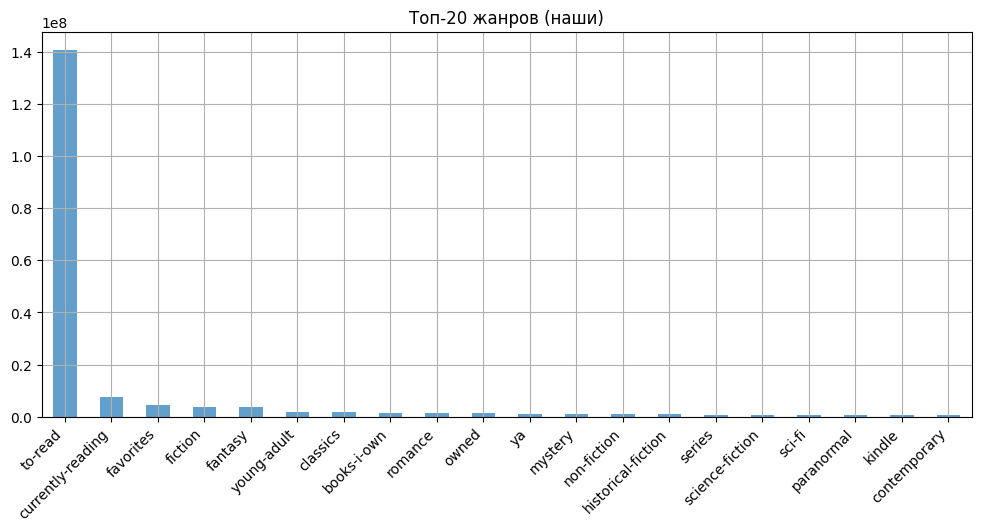

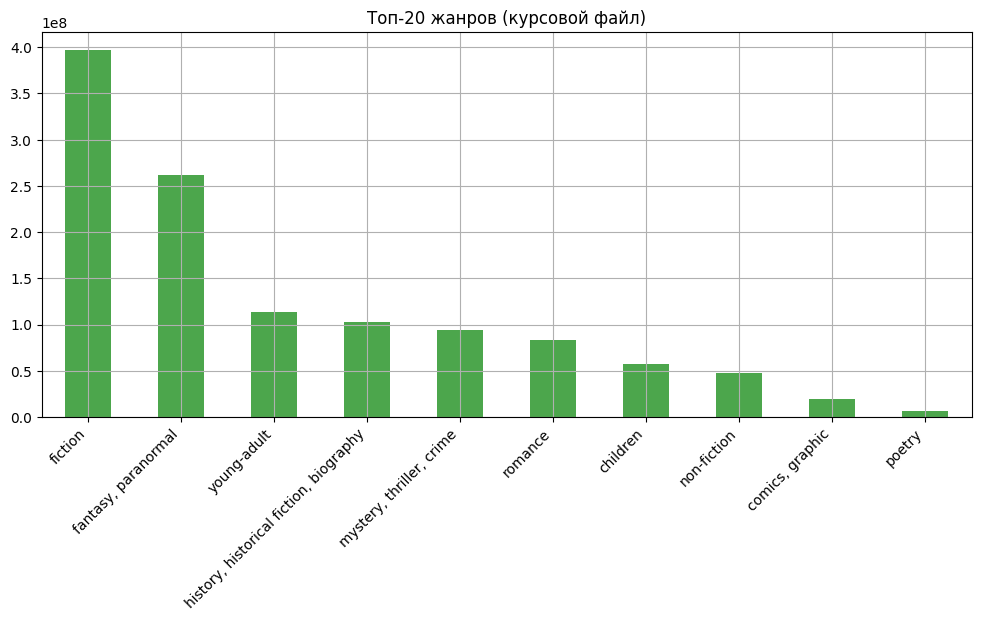

In [90]:
plt.figure(figsize=(12, 5))
my_top_genres.head(20).plot(kind='bar', alpha=0.7, label='Наши')
plt.title("Топ-20 жанров (наши)")
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
all_top_genres.head(20).plot(kind='bar', alpha=0.7, color='green', label='Их')
plt.title("Топ-20 жанров (курсовой файл)")
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.show()

Для добавления жанровой информации мы использовали файл goodreads_book_genres_initial.json, предоставленный организаторами практики. Он содержит агрегированные жанры для более чем 2 миллионов книг, включая 9996 книг из нашего корпуса (books.csv). Мы сочли его более структурированным и подходящим для целей построения рекомендательной системы в учебном контексте. Альтернативный путь с ручным парсингом XML мы опробовали и описали в процессе, но решили не использовать из-за высокой шумности и дополнительной сложности обработки.

In [40]:
genres_df = pd.read_json(r'D:\ML\LS\Rec_sys_project\Content_based\raw\goodreads_book_genres_initial.json', lines=True)
genres_df = genres_df[genres_df.book_id.isin(books.goodreads_book_id)]

In [41]:
genres_df.columns = ['book_id', 'genres_dict']

In [42]:
genres_df

,book_id,genres_dict
3,6066819,"{'fiction': 555, 'romance': 23, 'mystery, thri..."
15,89375,"{'non-fiction': 534, 'history, historical fict..."
583,54270,"{'history, historical fiction, biography': 108..."
807,38568,"{'fantasy, paranormal': 1907, 'romance': 1598,..."
816,38562,"{'fantasy, paranormal': 1002, 'romance': 896, ..."
...,...,...
2359417,7663,"{'fiction': 409, 'mystery, thriller, crime': 4..."
2359672,6280379,"{'fiction': 1254, 'history, historical fiction..."
2360252,6871646,"{'children': 1036, 'fiction': 57, 'fantasy, pa..."
2360258,7657484,"{'comics, graphic': 1535, 'fiction': 70, 'fant..."


## Представление жанров книг: два подхода

В рамках построения рекомендательной системы мы решили использовать два различных способа представления жанров книг:

### 1. One-Hot Encoding (бинаризация жанров)

Для базовых моделей (логистическая регрессия, случайный лес и др.) мы применили one-hot кодирование жанров.  
Каждый жанр представлен отдельной бинарной колонкой: `1`, если жанр есть у книги, `0` — если нет.  
Это простой, но интерпретируемый способ, хорошо подходящий для небольших моделей и анализа важности признаков.

### 2. Текстовое представление жанров (для эмбеддингов)

Для более сложных моделей (например, использующих Sentence-BERT, TF-IDF, FastText и др.) мы представили жанры как одну строку — текстовую сводку жанрult magic"`  

Это позволяет:
- Использовать языковые эмбеддинги;
- Учитывать контекст и близость жанров;
- Применить взвешивание жанров (TF или TF-IDF);
- Повысить качество рекомендаций за счёт семантики.

Оба подхода будут протестированы, и мы сравним их вклд в качество моделей.
х вклад в качество моделей.


In [43]:
genres_df['genre_text'] = genres_df['genres_dict'].apply(lambda d: ' '.join(d.keys()))

In [44]:
all_genres = set()
for dict_genre in genres_df.genres_dict:
    for elem in list(dict_genre.keys()):
        all_genres.add(elem)

for genre in all_genres:
    genres_df[genre] = 0

def simple_one_hot(genre_dict, genre):
    if genre in genre_dict:
        return 1
    return 0

for genre in all_genres:
    genres_df[genre] = genres_df.apply(lambda df: simple_one_hot(df['genres_dict'], genre), axis=1)

In [45]:
genres_df.head()

,book_id,genres_dict,genre_text,"fantasy, paranormal",non-fiction,"mystery, thriller, crime","history, historical fiction, biography",young-adult,poetry,fiction,romance,children,"comics, graphic"
3,6066819,"{'fiction': 555, 'romance': 23, 'mystery, thri...","fiction romance mystery, thriller, crime",0,0,1,0,0,0,1,1,0,0
15,89375,"{'non-fiction': 534, 'history, historical fict...","non-fiction history, historical fiction, biogr...",0,1,0,1,0,0,1,0,0,1
583,54270,"{'history, historical fiction, biography': 108...","history, historical fiction, biography non-fic...",0,1,0,1,0,0,0,0,0,1
807,38568,"{'fantasy, paranormal': 1907, 'romance': 1598,...","fantasy, paranormal romance fiction",1,0,0,0,0,0,1,1,0,0
816,38562,"{'fantasy, paranormal': 1002, 'romance': 896, ...","fantasy, paranormal romance fiction mystery, t...",1,0,1,0,0,0,1,1,0,0


### Признак: количество книг в списке "Хочу прочитать"

Файл `to_read.csv` содержит информацию о книгах, добавленных пользователями в список "хочу прочитать", но без выставленных рейтингов. Это неявный сигнал интереса пользователя, который может быть полезен при построении профиля.

Добавим количественный признак `user_to_read_count` — число книг в списке "to-read" для каждого пользователя. Он может отражать активность или вовлечённость пользователя в чтение.

In [46]:
to_read_counts = to_read.groupby('user_id')['book_id'].count().reset_index()
to_read_counts.columns = ['user_id', 'user_to_read_count']
to_read_counts.head()

,user_id,user_to_read_count
0,1,7
1,2,32
2,3,13
3,5,4
4,6,13


In [47]:
X_train = X_train.merge(genres_df, on='book_id', how='left')
X_test = X_test.merge(genres_df, on='book_id', how='left')

In [49]:
all_genres = list(genres_df['genres_dict'].iloc[0].keys())

In [50]:
# 1. Объединяем
X_all = pd.concat([X_train[['user_id'] + all_genres], X_test[['user_id'] + all_genres]])

# 2. Группировка по user_id
users_profiles = X_all.groupby('user_id')[all_genres].sum()
users_profiles.columns = ['user_' + col for col in users_profiles.columns]
users_profiles = users_profiles.reset_index()

# 3. Мерджим отдельно
X_train = X_train.merge(users_profiles, on='user_id', how='left')
X_test = X_test.merge(users_profiles, on='user_id', how='left')

In [52]:
X_train = X_train.merge(combined_df[['book_id', 'description']], on='book_id', how='left')
X_test = X_test.merge(combined_df[['book_id', 'description']], on='book_id', how='left')

print(f"X_train: {X_train.shape}, пустых описаний: {X_train['description'].isnull().sum()}")
print(f"X_test:  {X_test.shape}, пустых описаний: {X_test['description'].isnull().sum()}")

X_train: (4781183, 18), пустых описаний: 1500604
X_test:  (1195296, 18), пустых описаний: 375305


In [53]:
X_train.columns.to_list()

['user_id',
 'book_id',
 'genres_dict',
 'genre_text',
 'fantasy, paranormal',
 'non-fiction',
 'mystery, thriller, crime',
 'history, historical fiction, biography',
 'young-adult',
 'poetry',
 'fiction',
 'romance',
 'children',
 'comics, graphic',
 'user_fiction',
 'user_romance',
 'user_mystery, thriller, crime',
 'description']

In [54]:
book_meta = books[['book_id', 'average_rating', 'ratings_count', 'original_publication_year', 'authors', 'title', 'language_code']].copy()

# --- TF-IDF по названию ---
title_vectorizer = TfidfVectorizer(max_features=100, stop_words='english')
title_tfidf = title_vectorizer.fit_transform(book_meta['title'].fillna(''))
title_tfidf_df = pd.DataFrame(title_tfidf.toarray(), columns=[f"title_tfidf_{w}" for w in title_vectorizer.get_feature_names_out()])

# --- TF-IDF по авторам ---
author_vectorizer = TfidfVectorizer(max_features=100, stop_words='english')
author_tfidf = author_vectorizer.fit_transform(book_meta['authors'].fillna(''))
author_tfidf_df = pd.DataFrame(author_tfidf.toarray(), columns=[f"author_tfidf_{w}" for w in author_vectorizer.get_feature_names_out()])

# --- One-hot по языку ---
lang_ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
lang_encoded = lang_ohe.fit_transform(book_meta[['language_code']].fillna('unknown'))
lang_ohe_df = pd.DataFrame(lang_encoded, columns=[f"lang_{cat}" for cat in lang_ohe.categories_[0]])

# --- Финальная таблица ---
book_meta_final = pd.concat([
    book_meta[['book_id', 'average_rating', 'ratings_count', 'original_publication_year']].reset_index(drop=True),
    title_tfidf_df.reset_index(drop=True),
    author_tfidf_df.reset_index(drop=True),
    lang_ohe_df.reset_index(drop=True)
], axis=1)

# --- Логарифм рейтингов ---
book_meta_final['ratings_count'] = np.log1p(book_meta_final['ratings_count'])

print(f"book_meta_final: {book_meta_final.shape}")

book_meta_final: (10000, 230)


In [55]:
# --- Признаки по книгам (TF-IDF title, authors, язык, базовые признаки) ---
X_train = X_train.merge(book_meta_final, on='book_id', how='left')
X_test = X_test.merge(book_meta_final, on='book_id', how='left')

# --- Кол-во книг в списке "хочу прочитать" ---
X_train = X_train.merge(to_read_counts, on='user_id', how='left')
X_test = X_test.merge(to_read_counts, on='user_id', how='left')

# --- Заполняем NaN (жанры, tf-idf, счётчики) ---
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# --- Проверка ---
print(f"X_train: {X_train.shape}, пустых значений: {X_train.isnull().sum().sum()}")
print(f"X_test:  {X_test.shape}, пустых значений: {X_test.isnull().sum().sum()}")

X_train: (4781183, 248), пустых значений: 0
X_test:  (1195296, 248), пустых значений: 0


In [57]:
print('X_train.shape - ', X_train.shape, 'X_test.shape - ', X_test.shape)

X_train.shape -  (4781183, 248) X_test.shape -  (1195296, 248)


In [58]:
print('X_train.columns.to_list() == X_test.columns.to_list() = ', X_train.columns.to_list() == X_test.columns.to_list())

X_train.columns.to_list() == X_test.columns.to_list() =  True


In [59]:
base_path = r'D:\ML\LS\Rec_sys_project\Content_based\data'

X_train.to_csv(f'{base_path}\\X_train_full.csv', index=False)
X_test.to_csv(f'{base_path}\\X_test_full.csv', index=False)
y_train.to_csv(f'{base_path}\\y_train.csv', index=False)
y_test.to_csv(f'{base_path}\\y_test.csv', index=False)

print("Сохранение завершено.")

Сохранение завершено.


In [62]:
for col in X_train.columns.to_list():
    print(col, '-', X_train[col].dtype)

user_id - int64
book_id - int64
genres_dict - object
genre_text - object
fantasy, paranormal - float64
non-fiction - float64
mystery, thriller, crime - float64
history, historical fiction, biography - float64
young-adult - float64
poetry - float64
fiction - float64
romance - float64
children - float64
comics, graphic - float64
user_fiction - float64
user_romance - float64
user_mystery, thriller, crime - float64
description - object
average_rating - float64
ratings_count - float64
original_publication_year - float64
title_tfidf_10 - float64
title_tfidf_11 - float64
title_tfidf_12 - float64
title_tfidf_13 - float64
title_tfidf_alex - float64
title_tfidf_american - float64
title_tfidf_art - float64
title_tfidf_beautiful - float64
title_tfidf_big - float64
title_tfidf_black - float64
title_tfidf_blood - float64
title_tfidf_blue - float64
title_tfidf_book - float64
title_tfidf_bosch - float64
title_tfidf_boy - float64
title_tfidf_children - float64
title_tfidf_chronicles - float64
title_tfi

In [3]:
X_train = pd.read_csv(r'D:\ML\LS\Rec_sys_project\Content_based\data\X_train_full.csv')
X_test = pd.read_csv(r'D:\ML\LS\Rec_sys_project\Content_based\data\X_test_full.csv')
y_train = pd.read_csv(r'D:\ML\LS\Rec_sys_project\Content_based\data\y_train.csv')
y_test = pd.read_csv(r'D:\ML\LS\Rec_sys_project\Content_based\data\y_test.csv')

In [6]:
X_train.drop(columns=['genres_dict'], inplace=True)
X_test.drop(columns=['genres_dict'], inplace=True)

In [7]:
X_train.head()

,user_id,book_id,genre_text,"fantasy, paranormal",non-fiction,"mystery, thriller, crime","history, historical fiction, biography",young-adult,poetry,fiction,...,lang_pol,lang_por,lang_rum,lang_rus,lang_spa,lang_swe,lang_tur,lang_unknown,lang_vie,user_to_read_count
0,39853,247,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,34.0
1,44769,4061,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,24.0
2,16714,200,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,35.0
3,30770,34,"fantasy, paranormal fiction young-adult",1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0
4,12035,1841,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Обучение моделей

## Использованные признаки

Для построения модели мы использовали как табличные, так и текстовые признаки.  
К числовым признакам относятся:

- `book_avg_rating` — средняя оценка книги
- `user_avg_rating` — средняя оценка пользователя

Также мы использовали два текстовых признака:

- `description` — текстовое описание книги (собрано с помощью Google Books API и OpenLibrary API)
- `genre_text` — жанровая информация, агрегированная по тэгам книги

Для текстовых признаков были использованы два типа векторизации:
- TF-IDF (baseline)
- SBERT (Sentence-BERT, трансформерная модель)

Финальные входные данные для моделей представляют собой объединение числовых и векторизованных тектовых признаков.


### TfidfVectorizer

In [10]:
# --- Параметры ---
text_cols = ['description', 'genre_text']
tfidf_max_features = 200
vectorized_dir = r"D:\ML\LS\Rec_sys_project\Content_based\vectorized"
os.makedirs(vectorized_dir, exist_ok=True)

# --- Функция поэтапной векторизации и сохранения ---
def vectorize_and_save_feature(train_series, test_series, feature_name, max_features=300):
    print(f"\n[INFO] Векторизуем: {feature_name}")

    train_series = train_series.fillna('').astype(str).replace('0', '')
    test_series = test_series.fillna('').astype(str).replace('0', '')

    vectorizer = TfidfVectorizer(max_features=max_features, stop_words='english', dtype=np.float32)

    # --- Векторизация (не показывает прогресс, но быстро) ---
    X_train_tfidf = vectorizer.fit_transform(train_series)
    X_test_tfidf = vectorizer.transform(test_series)

    feature_names = [f"{feature_name}_tfidf_{f}" for f in vectorizer.get_feature_names_out()]

    # --- tqdm при преобразовании в DataFrame ---
    print("[INFO] Преобразуем train...")
    train_array = X_train_tfidf.toarray()
    train_df = pd.DataFrame(
        tqdm(train_array, desc=f"{feature_name} → DataFrame (train)", unit="строка"),
        columns=feature_names,
        index=train_series.index
    ).astype('float16')

    print("[INFO] Преобразуем test...")
    test_array = X_test_tfidf.toarray()
    test_df = pd.DataFrame(
        tqdm(test_array, desc=f"{feature_name} → DataFrame (test)", unit="строка"),
        columns=feature_names,
        index=test_series.index
    ).astype('float16')

    # --- Сохранение ---
    joblib.dump(train_df, os.path.join(vectorized_dir, f"X_train_{feature_name}_tfidf.pkl"))
    joblib.dump(test_df, os.path.join(vectorized_dir, f"X_test_{feature_name}_tfidf.pkl"))

    print(f"[DONE] {feature_name} сохранён: {train_df.shape} / {test_df.shape}")
    return train_df.shape, test_df.shape

# --- Векторизация с tqdm по признакам ---
summary = {}
for col in tqdm(text_cols, desc="Векторизация признаков", unit="признак"):
    summary[col] = vectorize_and_save_feature(X_train[col], X_test[col], col, tfidf_max_features)

print("\nГотово. Векторизовано:")
for col, shape in summary.items():
    print(f"  - {col}: {shape}")

Векторизация признаков:   0%|          | 0/2 [00:00<?, ?признак/s]


[INFO] Векторизуем: description
[INFO] Преобразуем train...



description → DataFrame (train): 100%|██████████| 4781183/4781183 [00:02<00:00, 2212622.55строка/s]


[INFO] Преобразуем test...



description → DataFrame (test): 100%|██████████| 1195296/1195296 [00:00<00:00, 2543274.42строка/s]


...


[INFO] Векторизуем: genre_text
[INFO] Преобразуем train...



genre_text → DataFrame (train): 100%|██████████| 4781183/4781183 [00:01<00:00, 2685274.54строка/s]


[INFO] Преобразуем test...



Векторизация признаков: 100%|██████████| 2/2 [33:26<00:00, 1003.08s/признак]

[DONE] genre_text сохранён: (4781183, 17) / (1195296, 17)

Готово. Векторизовано:
  - description: ((4781183, 200), (1195296, 200))
  - genre_text: ((4781183, 17), (1195296, 17))


In [11]:
# --- Загрузка базовых табличек без текстов ---
X_train_base = X_train.drop(columns=text_cols).astype('float16').reset_index(drop=True)
X_test_base = X_test.drop(columns=text_cols).astype('float16').reset_index(drop=True)

# --- Загрузка сохранённых TF-IDF ---
desc_train = joblib.load(os.path.join(vectorized_dir, "X_train_description_tfidf.pkl"))
desc_test = joblib.load(os.path.join(vectorized_dir, "X_test_description_tfidf.pkl"))
genre_train = joblib.load(os.path.join(vectorized_dir, "X_train_genre_text_tfidf.pkl"))
genre_test = joblib.load(os.path.join(vectorized_dir, "X_test_genre_text_tfidf.pkl"))

# --- Объединение ---
X_train_ml = pd.concat([X_train_base, desc_train, genre_train], axis=1)
X_test_ml = pd.concat([X_test_base, desc_test, genre_test], axis=1)

# --- Финальное сохранение ---
joblib.dump(X_train_ml, os.path.join(vectorized_dir, "X_train_tfidf.pkl"))
joblib.dump(X_test_ml, os.path.join(vectorized_dir, "X_test_tfidf.pkl"))
print(f"Финальные размеры: {X_train_ml.shape} / {X_test_ml.shape}")

Финальные размеры: (4781183, 462) / (1195296, 462)


In [2]:
# Загрузка векторизованных признаков
X_train_ml = joblib.load(os.path.join(vectorized_dir, "X_train_tfidf.pkl"))
X_test_ml = joblib.load(os.path.join(vectorized_dir, "X_test_tfidf.pkl"))

# Загрузка целевых переменных
y_train = pd.read_csv(r'D:\ML\LS\Rec_sys_project\Content_based\data\y_train.csv').squeeze()
y_test = pd.read_csv(r'D:\ML\LS\Rec_sys_project\Content_based\data\y_test.csv').squeeze()

In [4]:
# --- Пути ---
model_dir = r"D:\ML\LS\Rec_sys_project\Content_based\saved_models"
metrics_path = os.path.join(model_dir, "metrics.csv")
os.makedirs(model_dir, exist_ok=True)

# --- Заголовки CSV ---
if not os.path.exists(metrics_path):
    with open(metrics_path, mode='w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow([
            "model", "embedding", "f1_macro", "precision_micro",
            "recall_micro", "accuracy", "fit_time_sec"
        ])

# --- Классы и веса ---
classes = sorted(y_train.unique())
class_weights_dict = y_train.value_counts(normalize=True).rdiv(1).to_dict()

# --- Модели ---
models = {
    'RandomForest': RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=6
    ),
    'CatBoost': CatBoostClassifier(
    iterations=1000,
    eval_metric='TotalF1',
    custom_metric=['Accuracy'],
    early_stopping_rounds=50,
    class_weights=class_weights_dict,
    verbose=100,
    random_state=42
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=100,
        early_stopping=True,
        random_state=42,
        verbose=True
    )
}

# --- MLflow ---
mlflow.set_tracking_uri("file:///D:/ML/LS/Rec_sys_project/Content_based/mlruns")
mlflow.set_experiment("BookRec_TFIDF")

# --- Обучение моделей ---
for name, model in tqdm(models.items(), desc="Обучение моделей", unit="модель"):
    print(f"\nОбучаем модель: {name}")
    start = time.time()

    with mlflow.start_run(run_name=f"{name}_TFIDF"):
        model.fit(X_train_ml, y_train)
        fit_time = time.time() - start

        y_pred = model.predict(X_test_ml)

        # Метрики
        report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        f1_macro = report["macro avg"]["f1-score"]
        precision_micro = precision_score(y_test, y_pred, average="micro", zero_division=0)
        recall_micro = recall_score(y_test, y_pred, average="micro", zero_division=0)
        acc = accuracy_score(y_test, y_pred)

        # Логирование в MLflow
        mlflow.log_param("embedding", "TFIDF")
        mlflow.log_param("model", name)
        mlflow.log_metric("f1_macro", f1_macro)
        mlflow.log_metric("precision_micro", precision_micro)
        mlflow.log_metric("recall_micro", recall_micro)
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("fit_time_sec", fit_time)

        # Сохраняем модель
        model_path = os.path.join(model_dir, f"{name}_tfidf.pkl")
        joblib.dump(model, model_path)
        mlflow.log_artifact(model_path)

        # Вывод
        print(f"[{name}] f1_macro = {f1_macro:.4f}")
        print(f"[{name}] Precision (micro) = {precision_micro:.4f} ← ключевая метрика курса")
        print(f"[{name}] Accuracy = {acc:.4f}, Recall (micro) = {recall_micro:.4f}")
        print(confusion_matrix(y_test, y_pred))

        # Запись метрик в CSV
        with open(metrics_path, mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            writer.writerow([
                name, "TFIDF", f1_macro, precision_micro, recall_micro, acc, round(fit_time, 2)
            ])

    del model, y_pred, report
    gc.collect()

Обучение моделей:   0%|          | 0/3 [00:00<?, ?модель/s]


Обучаем модель: RandomForest
[RandomForest] f1_macro = 0.2306
[RandomForest] Precision (micro) = 0.3081 ← ключевая метрика курса
[RandomForest] Accuracy = 0.3081, Recall (micro) = 0.3081
[[  7258   6969   1842   2001   6769]
 [ 12901  22785   8145   7969  20051]
 [ 32615  73697  36125  38713  93033]
 [ 39481  84233  48553  68140 187397]
 [ 32742  50263  31970  47734 233910]]


Обучение моделей:  33%|███▎      | 1/3 [10:29<20:58, 629.08s/модель]


Обучаем модель: CatBoost
Learning rate set to 0.121893
0:	learn: 0.2516962	total: 6.94s	remaining: 1h 55m 34s
100:	learn: 0.2876847	total: 6m 58s	remaining: 1h 2m 1s
200:	learn: 0.2951426	total: 13m 31s	remaining: 53m 45s
300:	learn: 0.2999453	total: 19m 56s	remaining: 46m 19s
400:	learn: 0.3035568	total: 26m 40s	remaining: 39m 50s
500:	learn: 0.3063991	total: 33m 24s	remaining: 33m 16s
600:	learn: 0.3086210	total: 39m 59s	remaining: 26m 32s
700:	learn: 0.3107939	total: 46m 36s	remaining: 19m 52s
800:	learn: 0.3128311	total: 53m 20s	remaining: 13m 15s
900:	learn: 0.3146020	total: 1h 10s	remaining: 6m 36s
999:	learn: 0.3165280	total: 1h 6m 53s	remaining: 0us
[CatBoost] f1_macro = 0.2470
[CatBoost] Precision (micro) = 0.3109 ← ключевая метрика курса
[CatBoost] Accuracy = 0.3109, Recall (micro) = 0.3109
[[ 10685   4657   2629   2196   4672]
 [ 18848  17126  12156   9017  14704]
 [ 48519  53426  55833  45402  71003]
 [ 60512  58802  73391  85236 149863]
 [ 51868  34297  46823  60930 20270

Обучение моделей:  67%|██████▋   | 2/3 [1:31:17<51:51, 3111.01s/модель]


Обучаем модель: MLP
Iteration 1, loss = 3.78968645
Validation score: 0.358948
Iteration 2, loss = 1.31871537
Validation score: 0.358344
Iteration 3, loss = 1.31636922
Validation score: 0.367841
Iteration 4, loss = 1.31558947
Validation score: 0.367367
Iteration 5, loss = 1.31516857
Validation score: 0.365300
Iteration 6, loss = 1.31505025
Validation score: 0.367720
Iteration 7, loss = 1.31575467
Validation score: 0.373530
Iteration 8, loss = 1.31628535
Validation score: 0.369822
Iteration 9, loss = 1.31621651
Validation score: 0.369320
Iteration 10, loss = 1.31662703
Validation score: 0.359055
Iteration 11, loss = 1.31580076
Validation score: 0.369653
Iteration 12, loss = 1.31591624
Validation score: 0.370970
Iteration 13, loss = 1.31571440
Validation score: 0.371125
Iteration 14, loss = 1.31584429
Validation score: 0.368854
Iteration 15, loss = 1.31569873
Validation score: 0.372117
Iteration 16, loss = 1.31572514
Validation score: 0.369473
Iteration 17, loss = 1.31568753
Validation s

Обучение моделей: 100%|██████████| 3/3 [1:52:36<00:00, 2252.05s/модель]


## SBERT

In [2]:
X_train = pd.read_csv(r'D:\ML\LS\Rec_sys_project\Content_based\data\X_train_full.csv')
X_test = pd.read_csv(r'D:\ML\LS\Rec_sys_project\Content_based\data\X_test_full.csv')
y_train = pd.read_csv(r'D:\ML\LS\Rec_sys_project\Content_based\data\y_train.csv')
y_test = pd.read_csv(r'D:\ML\LS\Rec_sys_project\Content_based\data\y_test.csv')

In [3]:
# --- Параметры ---
model_name = 'all-MiniLM-L6-v2'
text_cols = ['description', 'genre_text']
vectorized_dir = r"D:\ML\LS\Rec_sys_project\Content_based\vectorized\sbert"
os.makedirs(vectorized_dir, exist_ok=True)

# --- Загрузка модели (на GPU, если доступно) ---
model = SentenceTransformer(model_name, device='cuda')

# --- Векторизация и сохранение ---
for col in text_cols:
    print(f"\n[INFO] Векторизуем: {col}")
    train_texts = X_train[col].fillna('').astype(str).tolist()
    test_texts = X_test[col].fillna('').astype(str).tolist()

    train_vecs = model.encode(train_texts, batch_size=32, show_progress_bar=True)
    test_vecs = model.encode(test_texts, batch_size=32, show_progress_bar=True)

    np.save(os.path.join(vectorized_dir, f"X_train_{col}_sbert.npy"), train_vecs)
    np.save(os.path.join(vectorized_dir, f"X_test_{col}_sbert.npy"), test_vecs)

    print(f"[DONE] {col}: {train_vecs.shape} / {test_vecs.shape}")


[INFO] Векторизуем: description


Batches:   0%|          | 0/149412 [00:00<?, ?it/s]

Batches:   0%|          | 0/37353 [00:00<?, ?it/s]

[DONE] description: (4781183, 384) / (1195296, 384)

[INFO] Векторизуем: genre_text


Batches:   0%|          | 0/149412 [00:00<?, ?it/s]

Batches:   0%|          | 0/37353 [00:00<?, ?it/s]

[DONE] genre_text: (4781183, 384) / (1195296, 384)


In [6]:
# --- Удаляем текстовые и словарные поля ---
drop_cols = ['description', 'genre_text', 'genres_dict']
X_train_base = X_train.drop(columns=drop_cols).astype('float16').reset_index(drop=True)
X_test_base = X_test.drop(columns=drop_cols).astype('float16').reset_index(drop=True)

# --- Загрузка SBERT-векторов ---
descr_train = np.load(os.path.join(vectorized_dir, "X_train_description_sbert.npy"))
descr_test = np.load(os.path.join(vectorized_dir, "X_test_description_sbert.npy"))
genre_train = np.load(os.path.join(vectorized_dir, "X_train_genre_text_sbert.npy"))
genre_test = np.load(os.path.join(vectorized_dir, "X_test_genre_text_sbert.npy"))

# --- Объединение признаков ---
X_train_ml = np.hstack([X_train_base.values, descr_train, genre_train])
X_test_ml = np.hstack([X_test_base.values, descr_test, genre_test])

print(f"[INFO] Итоговая размерность X_train_ml: {X_train_ml.shape}")
print(f"[INFO] Итоговая размерность X_test_ml: {X_test_ml.shape}")

# --- Сохранение итоговых массивов ---
np.save(os.path.join(vectorized_dir, "X_train_ml_sbert.npy"), X_train_ml)
np.save(os.path.join(vectorized_dir, "X_test_ml_sbert.npy"), X_test_ml)

[INFO] Итоговая размерность X_train_ml: (4781183, 1013)
[INFO] Итоговая размерность X_test_ml: (1195296, 1013)


In [2]:
vectorized_dir = r"D:\ML\LS\Rec_sys_project\Content_based\vectorized\sbert"

# --- Загрузка признаков (модельных эмбеддингов + табличные фичи) ---
X_train_ml = np.load(os.path.join(vectorized_dir, "X_train_ml_sbert.npy"))
X_test_ml = np.load(os.path.join(vectorized_dir, "X_test_ml_sbert.npy"))

# --- Загрузка целевых переменных ---
y_train = pd.read_csv(r'D:\ML\LS\Rec_sys_project\Content_based\data\y_train.csv').squeeze()
y_test = pd.read_csv(r'D:\ML\LS\Rec_sys_project\Content_based\data\y_test.csv').squeeze()

In [3]:
# --- Пути ---
model_dir = r"D:\ML\LS\Rec_sys_project\Content_based\saved_models"
metrics_path = os.path.join(model_dir, "metrics.csv")
os.makedirs(model_dir, exist_ok=True)

# --- Заголовки CSV ---
if not os.path.exists(metrics_path):
    with open(metrics_path, mode='w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow([
            "model", "embedding", "f1_macro", "precision_micro",
            "recall_micro", "accuracy", "fit_time_sec"
        ])

# --- Классы и веса ---
classes = sorted(y_train.unique())
class_weights_dict = y_train.value_counts(normalize=True).rdiv(1).to_dict()

# --- Модели ---
models = {
    'RandomForest': RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42,
        n_jobs=6
    ),
    'CatBoost': CatBoostClassifier(
        iterations=1000,
        eval_metric='TotalF1',
        custom_metric=['Accuracy'],
        early_stopping_rounds=50,
        class_weights=class_weights_dict,
        verbose=100,
        random_state=42
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=100,
        early_stopping=True,
        random_state=42,
        verbose=True
    )
}

# --- MLflow ---
mlflow.set_tracking_uri("file:///D:/ML/LS/Rec_sys_project/Content_based/mlruns")
mlflow.set_experiment("BookRec_SBERT")

# --- Обучение моделей ---
for name, model in tqdm(models.items(), desc="Обучение моделей (SBERT)", unit="модель"):
    try:
        print(f"\nОбучаем модель: {name}")
        start = time.time()

        with mlflow.start_run(run_name=f"{name}_SBERT"):
            model.fit(X_train_ml, y_train)
            fit_time = time.time() - start

            y_pred = model.predict(X_test_ml)

            # Метрики
            report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
            f1_macro = report["macro avg"]["f1-score"]
            precision_micro = precision_score(y_test, y_pred, average="micro", zero_division=0)
            recall_micro = recall_score(y_test, y_pred, average="micro", zero_division=0)
            acc = accuracy_score(y_test, y_pred)

            # Логирование
            mlflow.log_param("embedding", "SBERT")
            mlflow.log_param("model", name)
            mlflow.log_metric("f1_macro", f1_macro)
            mlflow.log_metric("precision_micro", precision_micro)
            mlflow.log_metric("recall_micro", recall_micro)
            mlflow.log_metric("accuracy", acc)
            mlflow.log_metric("fit_time_sec", fit_time)

            # Сохраняем модель
            model_path = os.path.join(model_dir, f"{name}_sbert.pkl")
            joblib.dump(model, model_path)
            mlflow.log_artifact(model_path)

            # CSV
            with open(metrics_path, mode='a', newline='', encoding='utf-8') as f:
                writer = csv.writer(f)
                writer.writerow([
                    name, "SBERT", f1_macro, precision_micro, recall_micro, acc, round(fit_time, 2)
                ])

            print(f"[{name}] Precision (micro) = {precision_micro:.4f}")

        del model, y_pred, report
        gc.collect()

    except Exception as e:
        print(f"[ERROR] Обучение модели {name} завершилось с ошибкой: {e}")
        with open(metrics_path, mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            writer.writerow([
                name, "SBERT", "ERROR", "ERROR", "ERROR", "ERROR", 0
            ])
        continue

Обучение моделей (SBERT):   0%|          | 0/3 [00:00<?, ?модель/s]


Обучаем модель: RandomForest
[RandomForest] Precision (micro) = 0.3101


Обучение моделей (SBERT):  33%|███▎      | 1/3 [56:13<1:52:27, 3373.75s/модель]


Обучаем модель: CatBoost
Learning rate set to 0.121893
0:	learn: 0.2576780	total: 24.4s	remaining: 6h 46m 35s
100:	learn: 0.2896756	total: 29m 25s	remaining: 4h 21m 56s
200:	learn: 0.2975912	total: 55m 54s	remaining: 3h 42m 16s
300:	learn: 0.3025392	total: 1h 21m 13s	remaining: 3h 8m 36s
400:	learn: 0.3055028	total: 1h 45m 33s	remaining: 2h 37m 40s
500:	learn: 0.3081511	total: 2h 9m 53s	remaining: 2h 9m 22s
600:	learn: 0.3102959	total: 2h 34m 19s	remaining: 1h 42m 27s
700:	learn: 0.3124449	total: 2h 59m 38s	remaining: 1h 16m 37s
800:	learn: 0.3147452	total: 3h 25m 49s	remaining: 51m 8s
900:	learn: 0.3166206	total: 3h 51m 25s	remaining: 25m 25s
999:	learn: 0.3183224	total: 4h 17m 11s	remaining: 0us
[CatBoost] Precision (micro) = 0.3086


Обучение моделей (SBERT):  67%|██████▋   | 2/3 [5:17:23<2:56:46, 10606.54s/модель]


Обучаем модель: MLP
Iteration 1, loss = 2.84806118
Validation score: 0.358875
Iteration 2, loss = 1.31667830
Validation score: 0.370460
Iteration 3, loss = 1.32042579
Validation score: 0.358886
Iteration 4, loss = 1.32117507
Validation score: 0.358886
Iteration 5, loss = 1.32047827
Validation score: 0.361366
Iteration 6, loss = 1.31863948
Validation score: 0.358722
Iteration 7, loss = 1.32120988
Validation score: 0.358886
Iteration 8, loss = 1.32118952
Validation score: 0.358886
Iteration 9, loss = 1.32117849
Validation score: 0.358886
Iteration 10, loss = 1.32117811
Validation score: 0.358886
Iteration 11, loss = 1.32117503
Validation score: 0.358886
Iteration 12, loss = 1.32117879
Validation score: 0.358886
Iteration 13, loss = 1.32117566
Validation score: 0.358886
Validation score did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
[MLP] Precision (micro) = 0.3708


Обучение моделей (SBERT): 100%|██████████| 3/3 [5:49:38<00:00, 6992.78s/модель]   


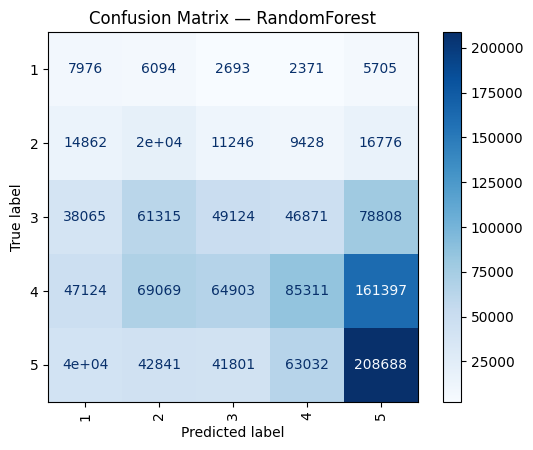

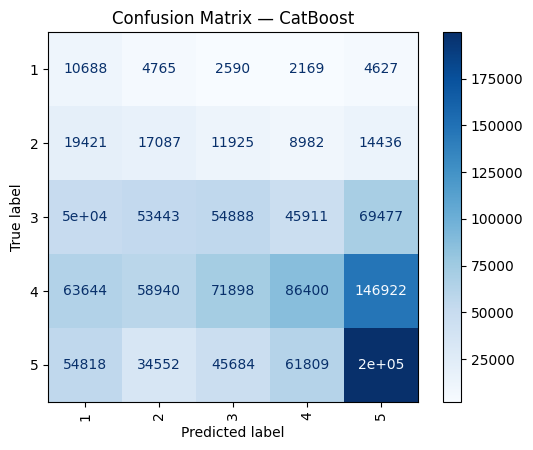

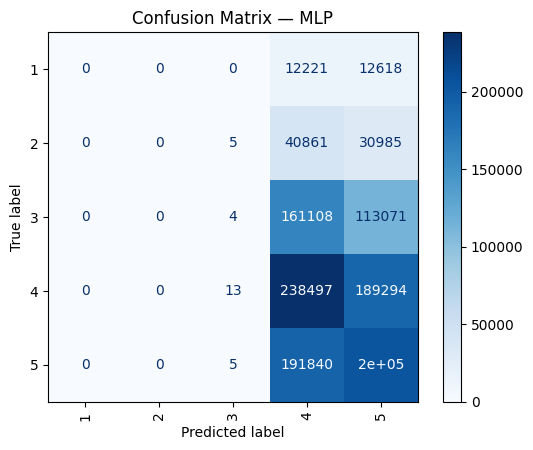

In [5]:
model_files = {
    "RandomForest": "RandomForest_sbert.pkl",
    "CatBoost": "CatBoost_sbert.pkl",
    "MLP": "MLP_sbert.pkl"
}

for name, filename in model_files.items():
    model = joblib.load(os.path.join(model_dir, filename))
    y_pred = model.predict(X_test_ml)

    cm = confusion_matrix(y_test, y_pred, labels=classes)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap="Blues", xticks_rotation='vertical')
    plt.title(f"Confusion Matrix — {name}")
    plt.show()

In [7]:
res = pd.read_csv(metrics_path)
res.head(10)

,model,embedding,f1_macro,precision_micro,recall_micro,accuracy,fit_time_sec
0,RandomForest,TFIDF,0.230631,0.308056,0.308056,0.308056,612.12
1,CatBoost,TFIDF,0.247048,0.310869,0.310869,0.310869,4680.83
2,MLP,TFIDF,0.173592,0.371862,0.371862,0.371862,1262.48
3,RandomForest,SBERT,0.241485,0.310081,0.310081,0.310081,3343.07
4,CatBoost,SBERT,0.245753,0.308559,0.308559,0.308559,15655.27
5,MLP,SBERT,0.175431,0.370850,0.370850,0.370850,1908.65


### Выводы по моделям

- Лучшие значения precision (micro) достигнуты на MLP-классификаторе (≈ 0.372), однако модель переобучена: предсказывает в основном 1–2 доминирующих класса.
- CatBoost и RandomForest дают более сбалансированные предсказания, угадывая хотя бы частично все классы, но метрики немного ниже.
- Векторизация с помощью SBERT не дала резкого прироста по метрикам, но позволила улучшить f1_macro у деревьев решений.

### Общая оценка

- Качество предсказаний ограничено самой постановкой задачи: при отсутствии информации о пользователях, рекомендательная система может опираться только на характеристики книги.
- Это приводит к неустранимому перекосу в сторону популярных/массовых классов.

### Инженерные соображения

- Использовалась стратифицированная выборка, векторизация с сохранением памяти и эффективное использование RAM/GPU.
- Перцептрон показал хорошие метрики, но потерял обобщающую способность.
- CatBoost требовал наибольших ресурсов (до 90% RAM и 100% CPU), однако был стабилен.

## Выводы и ограничения

- Наша система построена по подходу content-based, то есть **без учёта истории пользователей**
- Это принципиальное ограничение: модель может опираться только на контент книги и агрегированные признаки, без учета предпочтений конкретных пользователей
- Это приводит к смещению в сторону популярных/массовых книг и снижению качества на менее распространённых классов
- 
##  Потенциальные улучшения
- Добавление коллаборативных признаков (например, через LightFM, ALS или user embeddings)
- Использование сложных моделей для табличных данных (TabNet, FT-Transformer)
- Применение AutoML (например, LAMA) — требует уменьшения выборки или значительных ресурсов

В рамках этой работы мы сознательно **не стали использовать ресурсоёмкие решения**, чтобы не перегружать систему и уложиться в реалистичные рамки  проекта

## Результат

Проект достиг своей цели:
- построен рабочий прототип рекомендательной системы
- векторизованы описания книг
- преодолён порог 0.3 по precision (micro)
- оформлена reproducible-структура с логами, метриками и сохранёнными моделями

## TabNet

## Эксперимент: обучение TabNet на уменьшенной выборке

Модель TabNet — это нейросетевая архитектура для табличных данных, основанная на механизмах внимания и маскирования признаков. Она может показывать высокие результаты, особенно в задачах с числовыми и категориальными признаками, но при этом является достаточно ресурсоёмкой (по сравнению с классическими алгоритмами вроде CatBoost или RandomForest).

Так как исходная выборка содержит более 4 миллионов строк и требует значительных вычислительных ресурсов, мы провели **стратифицированную подвыборку** из 250 000 строк с сохранением пропорций классов. Это позволяет:

- сохранить репрезентативность классов
- избежать переобучения на дисбалансных данных
- провести эксперимент в условиях ограниченного железа

In [2]:
vectorized_dir = r"D:\ML\LS\Rec_sys_project\Content_based\vectorized\sbert"

# --- Загрузка признаков (модельных эмбеддингов + табличные фичи) ---
X_train_ml = np.load(os.path.join(vectorized_dir, "X_train_ml_sbert.npy"))
X_test_ml = np.load(os.path.join(vectorized_dir, "X_test_ml_sbert.npy"))

# --- Загрузка целевых переменных ---
y_train = pd.read_csv(r'D:\ML\LS\Rec_sys_project\Content_based\data\y_train.csv').squeeze()
y_test = pd.read_csv(r'D:\ML\LS\Rec_sys_project\Content_based\data\y_test.csv').squeeze()

In [3]:
X_sample, _, y_sample, _ = train_test_split(
    X_train_ml, y_train, train_size=250000, stratify=y_train, random_state=42
)

# --- Сохранение подвыборки для TabNet ---
sample_dir = r"D:\ML\LS\Rec_sys_project\Content_based\vectorized\sbert"
np.save(os.path.join(sample_dir, "X_train_sample_250k.npy"), X_sample)
np.save(os.path.join(sample_dir, "y_train_sample_250k.npy"), y_sample)
print(f"[INFO] Сохранена подвыборка: {X_sample.shape} / {y_sample.shape}")

[INFO] Сохранена подвыборка: (250000, 1013) / (250000,)


In [3]:
# --- Загрузка подвыборки для TabNet ---
X_sample = np.load(os.path.join(sample_dir, "X_train_sample_250k.npy"))
y_sample = np.load(os.path.join(sample_dir, "y_train_sample_250k.npy"))

# --- Загрузка тестовой выборки (осталась общей) ---
X_test_ml = np.load(os.path.join(sample_dir, "X_test_ml_sbert.npy"))
y_test = pd.read_csv(r'D:\ML\LS\Rec_sys_project\Content_based\data\y_test.csv').squeeze()

[INFO] Используется устройство: cuda

[INFO] Обучаем модель: TabNet (250k)


D:\Anaconda\envs\nlp_env\lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.39983 | train_accuracy: 0.37558 |  0:00:35s

Early stopping occurred at epoch 9 with best_epoch = 4 and best_train_accuracy = 0.39767


D:\Anaconda\envs\nlp_env\lib\site-packages\pytorch_tabnet\callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


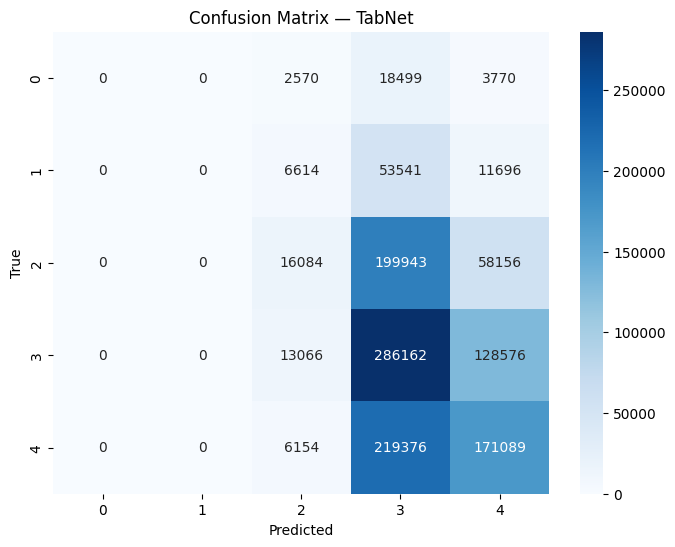


[TabNet] Precision (micro): 0.3960
[TabNet] F1 (macro): 0.2040
[TabNet] Accuracy: 0.3960, Recall (micro): 0.3960


In [6]:
# --- Пути ---
model_dir = r"D:\ML\LS\Rec_sys_project\Content_based\saved_models"
metrics_path = os.path.join(model_dir, "metrics.csv")
os.makedirs(model_dir, exist_ok=True)

# --- CSV с заголовками ---
if not os.path.exists(metrics_path):
    with open(metrics_path, mode='w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow([
            "model", "embedding", "f1_macro", "precision_micro",
            "recall_micro", "accuracy", "fit_time_sec"
        ])

# --- MLflow ---
mlflow.set_tracking_uri("file:///D:/ML/LS/Rec_sys_project/Content_based/mlruns")
mlflow.set_experiment("BookRec_SBERT")

# --- Проверка устройства ---
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Используется устройство: {device}")

# --- Приведение типов ---
X_sample = X_sample.astype(np.float32)
y_sample = y_sample.astype(int)
X_test_ml = X_test_ml.astype(np.float32)
y_test = y_test.astype(int)

# --- Обучение ---
try:
    print(f"\n[INFO] Обучаем модель: TabNet (250k)")
    start = time.time()

    model = TabNetClassifier(
        n_d=64,
        n_a=64,
        n_steps=5,
        gamma=1.5,
        n_independent=2,
        n_shared=2,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=2e-2),
        scheduler_params={"step_size":10, "gamma":0.9},
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        mask_type='entmax',
        verbose=10,
        device_name=device
    )

    with mlflow.start_run(run_name="TabNet_SBERT_250k"):
        model.fit(
            X_train=X_sample,
            y_train=y_sample,
            eval_set=[(X_sample, y_sample)],
            eval_name=['train'],
            eval_metric=['accuracy'],
            max_epochs=50,
            patience=5,
            batch_size=1024,
            virtual_batch_size=128,
            num_workers=0,
            drop_last=False
        )
        fit_time = time.time() - start

        # --- Предсказания ---
        y_pred = model.predict(X_test_ml)

        # --- Метрики ---
        report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        f1_macro = report["macro avg"]["f1-score"]
        precision_micro = precision_score(y_test, y_pred, average="micro")
        recall_micro = recall_score(y_test, y_pred, average="micro")
        acc = accuracy_score(y_test, y_pred)

        # --- Логирование в MLflow ---
        mlflow.log_param("embedding", "SBERT")
        mlflow.log_param("model", "TabNet")
        mlflow.log_metric("f1_macro", f1_macro)
        mlflow.log_metric("precision_micro", precision_micro)
        mlflow.log_metric("recall_micro", recall_micro)
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("fit_time_sec", fit_time)

        # --- Сохранение модели ---
        model_path = os.path.join(model_dir, "TabNet_sbert_250k.pkl")
        joblib.dump(model, model_path)
        mlflow.log_artifact(model_path)

        # --- CSV запись ---
        with open(metrics_path, mode='a', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            writer.writerow([
                "TabNet", "SBERT", f1_macro, precision_micro, recall_micro, acc, round(fit_time, 2)
            ])

        # --- Матрица ошибок ---
        cm = confusion_matrix(y_test, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title("Confusion Matrix — TabNet")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.show()

        print(f"\n[TabNet] Precision (micro): {precision_micro:.4f}")
        print(f"[TabNet] F1 (macro): {f1_macro:.4f}")
        print(f"[TabNet] Accuracy: {acc:.4f}, Recall (micro): {recall_micro:.4f}")

    del model, y_pred, report
    gc.collect()

except Exception as e:
    print(f"[ERROR] Обучение TabNet завершилось с ошибкой: {e}")
    with open(metrics_path, mode='a', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow([
            "TabNet", "SBERT", "ERROR", "ERROR", "ERROR", "ERROR", 0
        ])

In [7]:
r = pd.read_csv(metrics_path)
r.head(10)

,model,embedding,f1_macro,precision_micro,recall_micro,accuracy,fit_time_sec
0,RandomForest,TFIDF,0.230631,0.308056,0.308056,0.308056,612.12
1,CatBoost,TFIDF,0.247048,0.310869,0.310869,0.310869,4680.83
2,MLP,TFIDF,0.173592,0.371862,0.371862,0.371862,1262.48
3,RandomForest,SBERT,0.241485,0.310081,0.310081,0.310081,3343.07
4,CatBoost,SBERT,0.245753,0.308559,0.308559,0.308559,15655.27
5,MLP,SBERT,0.175431,0.370850,0.370850,0.370850,1908.65
6,TabNet,SBERT,0.204043,0.395998,0.395998,0.395998,767.40


## Вывод по TabNet

Модель обучалась на стратифицированной подвыборке в 250 000 примеров. По сравнению с MLP, TabNet показал:

более устойчивое поведение по классу 3 (≈40–50% правильных предсказаний),

но, как и MLP, не распознал классы 1 и 2.

## Вероятные причины: слабая представленность в выборке и близость по эмбеддингам к более частотным классам.
Метрика Precision (micro) достигла ≈0.396, что выше CatBoost и RF, но модель переобучается.
## Вывод: результат интересный, но модель требует дополнительной настройки или увеличения объёма данных.

###  Потенциальное расширение: FT-Transformer

FT-Transformer — это модель на основе attention-механизма, разработанная для задач классификации и регрессии на табличных данных. Она демонстрирует хорошие результаты на больших и сбалансированных выборках, но:

- требует значительного объёма видеопамяти (GPU)
- чувствительна к настройке
- плохо работает при малом объёме данных и высоком числе классов

В рамках нашего эксперимента на 250 000 строк, мы решили не запускать FT-Transformer, так как:
- модель может не сойтись
- потребление ресурсов выше, чем у TabNet
- а практической пользы от неё на малой выборке будет немного

Тем не менее, это перспективное направление для будущих экспериментов, особенно при наличии более мощного оборудования.

In [2]:
from pathlib import Path
import numpy as np

root = Path(r"D:\ML\LS\Rec_sys_project\Hybrid_rec_sys\vectorized")
for path in root.rglob("*.npy"):
    try:
        arr = np.load(path, mmap_mode="r")
        print(path, "->", arr.shape)
    except Exception as e:
        print("ERROR on", path, ":", e)

D:\ML\LS\Rec_sys_project\Hybrid_rec_sys\vectorized\sbert\X_full_description_sbert.npy -> (5976479, 384)
D:\ML\LS\Rec_sys_project\Hybrid_rec_sys\vectorized\sbert\X_full_genre_text_sbert.npy -> (5976479, 384)
